# Adversarial Evaluation Report

**System under test:** customer support ticket classifier (text in, structured JSON out).

This notebook reads previously generated results from `results/` and does not
call the model. To reproduce the results, run the evaluation runner first:

`python -m evals.runner --prompt v1`

## 0. System under test

The system classifies one e-commerce support ticket into a `category` (payment, delivery, account,
product_defect, refund, other) and a `priority` (low, medium, high), and returns a `confidence` and an
`evidence_span`. Output is validated against a Pydantic schema (`app/schema.py`). The model is
`gemini-3.5-flash-lite`; the prompts are versioned constants in `app/prompts.py` (v1 baseline, v2 targeted fixes).

### Deliberate design decision: a verbatim evidence span that is never repaired

The model must copy, character for character, the part of the ticket that justifies its category. The
classifier never corrects or fuzzy-matches that span before the harness sees it.

A naive implementation would return only the label, or ask for a free-text "reason". A label alone gives
nothing to verify, and a free-text reason cannot be checked programmatically: the model can write a fluent
justification for any label. A verbatim span turns "did the model ground its answer in the input?" into a
per-case test the harness can run without another LLM call.

This decision is what exposed the most serious failure in this report. Given an empty ticket (`adv_222`),
v2 answered `delivery` / `high` at 0.95 confidence, and its evidence span was a sentence from its own system
prompt. With label-only output this would have looked like an ordinary misclassification.

### Determinism

Every call uses temperature 0, top_p 1, seed 42 and the lowest thinking level the API accepts. Every response
is cached on disk, keyed on the model, prompt text, input, generation settings and output schema, and the
runner writes all raw responses before any metric is computed.

Gemini does not guarantee bit-identical output for a fixed seed across serving changes. The reported numbers
are reproducible because the cached responses are replayed; the run-to-run variance of fresh, uncached calls
was not measured.

In [1]:
import json, pathlib, os
from IPython.display import Image, Markdown, display

if pathlib.Path.cwd().name == 'report':
    os.chdir('..')

R = pathlib.Path('results')
VERSION = 'v1'

raw = json.loads((R / f'raw_results_{VERSION}.json').read_text(encoding='utf-8'))
results = raw['results']
m = json.loads((R / f'metrics_{VERSION}.json').read_text(encoding='utf-8'))
clusters = json.loads((R / f'failure_clusters_{VERSION}.json').read_text(encoding='utf-8'))

acc, hal, cal = m['accuracy'], m['hallucination'], m['calibration']


# Tables are rendered as Markdown instead of pandas DataFrames. pandas imports
# numpy.random, whose compiled DLLs Windows Smart App Control blocks on some
# machines, and a report that cannot open is worse than a plainer table.
def table(rows, columns):
    def cell(v):
        if isinstance(v, float):
            return f'{v:.4g}'
        return '' if v is None else str(v).replace('|', '\\|').replace('\n', ' ')
    lines = ['| ' + ' | '.join(columns) + ' |', '|' + '---|' * len(columns)]
    lines += ['| ' + ' | '.join(cell(r.get(c)) for c in columns) + ' |' for r in rows]
    display(Markdown('\n'.join(lines)))


table([{'field': k, 'value': v} for k, v in raw['meta'].items()], ['field', 'value'])

| field | value |
|---|---|
| model | gemini-3.5-flash-lite |
| seed | 42 |
| prompt_version | v1 |
| n_cases | 274 |
| seconds | 1171 |
| run_started_utc | 2026-09-13T10:18:34+00:00 |
| classifier_stats | {'cache_hits': 0, 'api_calls': 274, 'retries': 0} |

## 1. Executive summary

Once the prompt states explicit root-cause tie-break rules, category classification is reliable: v2 labels all
52 clean tickets correctly and 98.9% of all 274 cases (v1: 92.3% and 92.0%). Priority is the real weakness:
v1 got 61.3% and v2 78.8%, and about three in four priority errors are under-escalations, such as a refund two
weeks overdue rated medium instead of high. The most important failure is `adv_222`: given an empty ticket,
v2 answered `delivery` / `high` at 0.95 confidence and quoted a sentence from its own system prompt as
evidence. Confidence cannot be trusted in either version: v1 stated 0.85 or higher on 21 of its 22 wrong
answers, and v2's off-domain rule made it systematically underconfident (ECE 0.031 → 0.129).

| metric | v1 | v2 |
|---|---|---|
| category accuracy (all 274) | 92.0% | 98.9% |
| category accuracy (52 clean) | 92.3% | 100% |
| category accuracy (222 adversarial) | 91.9% | 98.7% |
| priority accuracy | 61.3% | 78.8% |
| hallucination rate | 0.4% (1 case) | 0.4% (1 case) |
| ECE | 0.031 | 0.129 |

One caveat applies to every v2 number: the v2 rules were written after reading v1's failures on these same
cases, so v2 is not evaluated on held-out data (see section 9).

The cells below load `VERSION = 'v1'`. Set it to `'v2'` in the first code cell to see the same views for v2.

In [2]:
summary = {
    'category accuracy (all)':         acc['overall_category_accuracy'],
    'category accuracy (clean)':       acc['normal_accuracy'],
    'category accuracy (adversarial)': acc['adversarial_accuracy'],
    'priority accuracy':               acc['overall_priority_accuracy'],
    'exact match (both fields)':       acc['overall_exact_accuracy'],
    'hallucination rate':              hal['hallucination_rate'],
    'ECE':                             cal['ece'],
    'MCE':                             cal['mce'],
    'mean overconfidence':             cal['mean_overconfidence'],
    'test cases':                      acc['n_total'],
}
table([{'metric': k, 'value': v} for k, v in summary.items()], ['metric', 'value'])

| metric | value |
|---|---|
| category accuracy (all) | 0.9197 |
| category accuracy (clean) | 0.9231 |
| category accuracy (adversarial) | 0.9189 |
| priority accuracy | 0.6131 |
| exact match (both fields) | 0.573 |
| hallucination rate | 0.0036 |
| ECE | 0.0308 |
| MCE | 0.9 |
| mean overconfidence | -0.0053 |
| test cases | 274 |

## 2. Ground truth construction

The ground-truth dataset contains 52 manually reviewed cases. Each case has an
expected category, priority, and a written rationale explaining the labeling
decision. Cases are also tagged by difficulty (easy, arguable, or hard) to
distinguish straightforward examples from cases where category or priority
boundaries are intentionally ambiguous.

Priority labels follow the rules below:

| priority | rule |
|---|---|
| high | money lost, access blocked, account compromised, product unusable or unsafe, or a stated deadline within 48 hours |
| medium | a real problem or time-sensitive request, but service is only degraded or delayed and nothing is lost yet |
| low | information requests, feedback, and minor complaints that leave the customer unaffected |

### How it was built

The candidate tickets and labels were drafted with an LLM. Every one of the 52 cases was then reviewed by
hand: the ticket wording, the category, the priority and the `label_reason` were each checked against the
rules above and corrected where they disagreed. No case was kept without a written rationale that names the
rule deciding it. No LLM output was used as a label without that review.

### What changed during review

The most common correction was on tickets that mix categories. Many drafted tickets carried signals for two
categories at once, such as a charge and a missing parcel, or the word "refund" next to a request for a missing
part. The draft either left them ambiguous or chose a label by the most prominent word. During review, every
such ticket was given **exactly one category**, decided by a single policy: classify by the customer's
underlying goal or root cause, not by the most prominent word. The rejected category is named in the
`label_reason`, so each decision can be challenged on its own terms.

| case | ticket (short) | signals present | label | why |
|---|---|---|---|---|
| `gt_049` | not received, already charged | delivery, payment | delivery | the missing parcel is the root cause; the charge is normal |
| `gt_052` | "not asking for a refund", wants the missing part | refund, product_defect | product_defect | refund is explicitly rejected; the goal is a working product |
| `gt_050` | "not defective", but the wrong model | product_defect, delivery | delivery | the item works; the wrong item was shipped |
| `gt_002` | payment failed but amount deducted | payment, refund | payment | no refund has been requested or promised yet |
| `gt_031` | chair leg missing from the box | product_defect, delivery | product_defect | the box arrived; its contents were incomplete |
| `gt_041` | return pickup never came | refund, delivery | refund | the customer's goal is the refund, not the courier visit |
| `gt_026` | loyalty points reset to zero | account, payment | account | no currency was charged |

By my count, 13 of the 23 cases tagged arguable or hard are category-boundary cases like these; the other 10 are
priority judgement calls, such as `gt_013` (a delivery-address change rated medium rather than low). The
category-boundary cases are also where the evaluation found most of v1's errors (section 7, cluster A): the model
faced the same two-category choice and, without the root-cause rule, picked the more prominent topic.

### Why I trust it

- **Every label can be audited.** Each case records the rule that decided it, so a reviewer can disagree with a
  specific rule instead of a gut call.
- **Mixed-category tickets follow one rule**, applied the same way across all 52 cases, instead of being
  decided case by case.
- **Priority follows a fixed checklist**, not a feeling about urgency.
- **Ambiguity is labelled, not hidden.** 23 cases are tagged arguable (12) or hard (11), and the report
  separates them. Both prompt versions got all 29 easy cases right, which is weak evidence that the easy labels
  are not mislabelled.

### Where I do not trust it

- **One reviewer.** No second labeller and no agreement score.
- **One category per ticket is a simplification.** A ticket like `gt_049` genuinely involves both delivery and
  payment. Forcing one label means a model that picks the other defensible category is scored as wrong. A
  `secondary_category` field would fix this (section 7, cluster A).
- **LLM-drafted tickets are cleaner than real ones:** short, one issue each, standard English. Real tickets are
  messier, so these results likely overstate real-world accuracy.
- **Contestable category labels:** `gt_041` (a missed return pickup labelled refund, arguably delivery),
  `gt_032` (a product safety question forced into product_defect), `gt_047` (an app crash labelled other),
  `gt_009` (a missing GSTIN on an invoice labelled payment).
- **Priority is less certain than category.** Several of v2's remaining clean-input priority misses (`gt_004`,
  `gt_009`, `gt_012`, `gt_015`) are cases where a second labeller could reasonably agree with the model.
  `gt_010` ("nine days late" treated as lost, so high) encodes a policy choice, not a fact.

In [3]:
from collections import Counter

gt = json.loads(pathlib.Path('data/ground_truth.json').read_text(encoding='utf-8'))
priorities = ['high', 'medium', 'low']
counts = Counter((c['expected']['category'], c['expected']['priority']) for c in gt)
categories = sorted({c['expected']['category'] for c in gt})

rows = [{'category': cat, **{p: counts[(cat, p)] for p in priorities},
         'total': sum(counts[(cat, p)] for p in priorities)} for cat in categories]
rows.append({'category': '**total**', **{p: sum(counts[(c, p)] for c in categories) for p in priorities},
             'total': len(gt)})
table(rows, ['category', *priorities, 'total'])

difficulty = Counter(c['difficulty'] for c in gt)
table([{'difficulty': d, 'cases': n} for d, n in difficulty.most_common()], ['difficulty', 'cases'])

| category | high | medium | low | total |
|---|---|---|---|---|
| account | 3 | 3 | 2 | 8 |
| delivery | 5 | 4 | 2 | 11 |
| other | 0 | 1 | 5 | 6 |
| payment | 4 | 4 | 2 | 10 |
| product_defect | 6 | 1 | 2 | 9 |
| refund | 3 | 3 | 2 | 8 |
| **total** | 21 | 16 | 15 | 52 |

| difficulty | cases |
|---|---|
| easy | 29 |
| arguable | 12 |
| hard | 11 |

## 3. Adversarial methodology

Each adversarial family targets a specific hypothesized weakness:

| family | what it changes | weakness it targets |
|---|---|---|
| paraphrase | wording only | sensitivity to surface form |
| irrelevant_context | adds unrelated text containing vocabulary from other categories | distraction and keyword bias |
| contradiction | appends conflicting information | handling of conflicting evidence |
| negation | introduces a decoy category inside a negated clause | keyword matching without understanding scope |
| typos | introduces character-level noise | input brittleness and evidence extraction |
| ood | replaces the support request with an off-domain input | inappropriate confidence outside the task domain |

For derived adversarial cases, the expected label is inherited from the
human-verified base case. The generator never asks an LLM to determine the
ground-truth label.

Paraphrases are generated with an LLM, disclosed as such, and stored in
`data/adversarial.json` so they can be inspected and reproduced without
regenerating them.

### Mapping to the required input types

| required | covered by | cases |
|---|---|---|
| paraphrased clean inputs | paraphrase | 52 |
| injected irrelevant context | irrelevant_context | 52 |
| subtle factual errors | contradiction: a sentence that makes the ticket's own facts inconsistent ("Though my bank statement shows no such transaction at all.") | 38 |
| edge of the distribution | ood (off-domain, gibberish, prompt injection, empty input) and typos (noisy in-domain input) | 8 + 52 |
| (extra) keyword scope | negation | 20 |

### How adversarial the families turned out to be

- **The negation family found nothing:** 100% in both versions. Its templates put the decoy in a separate
  sentence ("This is not a refund request."), which is easy to scope. The negation failures that did appear came
  from paraphrase and typo variants of the negated ground-truth cases (`adv_050`, `adv_212`).
- **One distractor is not irrelevant.** "My password manager keeps logging me out of everything these days"
  reads like a genuine account complaint. `adv_097` fails on it in both versions, and that case is arguably
  mislabelled by the generator, not a model error.
- **Inherited labels can be wrong.** In `adv_118` a contradiction was appended to a plain question about delivery
  charges, so the conflict barely makes sense and keeping the base label `delivery` is questionable.
- **Paraphrases come from the model family under test**, so they may be easier for it than human rewrites.

In [4]:
rows = [{'input_type': t, **v} for t, v in acc['by_input_type'].items()]
rows.sort(key=lambda r: r['category_accuracy'])
table(rows, ['input_type', 'n', 'category_accuracy', 'priority_accuracy', 'mean_confidence'])

| input_type | n | category_accuracy | priority_accuracy | mean_confidence |
|---|---|---|---|---|
| typos | 52 | 0.8654 | 0.5962 | 0.9365 |
| paraphrase | 52 | 0.9038 | 0.6154 | 0.9346 |
| contradiction | 38 | 0.9211 | 0.6053 | 0.8671 |
| normal | 52 | 0.9231 | 0.6154 | 0.9365 |
| irrelevant_context | 52 | 0.9423 | 0.5769 | 0.9058 |
| negation | 20 | 1 | 0.6 | 0.95 |
| ood | 8 | 1 | 1 | 0.6875 |

### Accuracy by input type, v1 vs v2

| input type | n | v1 category | v2 category | v1 mean conf | v2 mean conf |
|---|---|---|---|---|---|
| typos | 52 | 86.5% | 100% | 0.94 | 0.88 |
| paraphrase | 52 | 90.4% | 100% | 0.93 | 0.88 |
| contradiction | 38 | 92.1% | 97.4% | 0.87 | 0.79 |
| normal | 52 | 92.3% | 100% | 0.94 | 0.90 |
| irrelevant_context | 52 | 94.2% | 98.1% | 0.91 | 0.88 |
| negation | 20 | 100% | 100% | 0.95 | 0.95 |
| ood | 8 | 100% | 87.5% | 0.69 | 0.32 |

- **Adversarial accuracy on v1 (91.9%) is almost the same as clean accuracy (92.3%).** That does not mean the
  attacks failed: 10 of v1's 18 adversarial failures are variants of the 4 clean tickets v1 already got wrong.
  The attacks mostly re-exposed an existing weakness instead of creating new ones (section 7).
- **Typos were the most damaging family on v1**, with confidence unchanged at 0.94: the model did not notice it
  was working from damaged input.
- **v2's drop on ood (100% → 87.5%) is a single case**, the empty input `adv_222` (section 5).
- **Priority accuracy stays lowest on the attacks that add sentences:** negation 65% and contradiction 68% on v2,
  against 81% on clean input.

## 4. Results by category and confusion matrix

In [5]:
table([{'category': c, **v} for c, v in acc['per_class'].items()],
      ['category', 'support', 'precision', 'recall', 'f1'])

labels = list(acc['confusion'])
display(Markdown('Confusion matrix: rows are the gold label, columns the predicted label.'))
table([{'gold \\ predicted': g, **acc['confusion'][g]} for g in labels], ['gold \\ predicted', *labels])

| category | support | precision | recall | f1 |
|---|---|---|---|---|
| payment | 59 | 0.9833 | 1 | 0.9916 |
| delivery | 64 | 0.8714 | 0.9531 | 0.9104 |
| account | 34 | 0.9706 | 0.9706 | 0.9706 |
| product_defect | 45 | 0.8636 | 0.8444 | 0.8539 |
| refund | 40 | 1 | 0.9 | 0.9474 |
| other | 32 | 0.8333 | 0.7812 | 0.8064 |

Confusion matrix: rows are the gold label, columns the predicted label.

| gold \ predicted | payment | delivery | account | product_defect | refund | other |
|---|---|---|---|---|---|---|
| payment | 59 | 0 | 0 | 0 | 0 | 0 |
| delivery | 1 | 61 | 0 | 2 | 0 | 0 |
| account | 0 | 0 | 33 | 0 | 0 | 1 |
| product_defect | 0 | 3 | 0 | 38 | 0 | 4 |
| refund | 0 | 4 | 0 | 0 | 36 | 0 |
| other | 0 | 2 | 1 | 4 | 0 | 25 |

### What the per-class results show

- **On v1, the weakest classes are `other` (F1 0.81) and `product_defect` (F1 0.85).** Their errors sit on two
  boundaries: `product_defect` ↔ `other` (an app crash, a blender safety question) and `refund` → `delivery`
  (a return pickup nobody came for). Payment is near perfect in both versions.
- **v2 raises every class to F1 0.95 or higher.** All three remaining v2 errors involve `other`:
  `adv_097` (other → account), `adv_118` (delivery → other) and `adv_222` (other → delivery).
- **By difficulty on clean input:** v1 got every easy (29/29) and arguable (12/12) case right, but only 7 of the
  11 hard cases. All of v1's clean failures are hard cases. v2 gets 11/11, but its rules were written with these
  cases in view.

### Priority: the largest failure mode by count

| | v1 | v2 |
|---|---|---|
| priority errors | 106 / 274 | 58 / 274 |
| under-escalated (predicted lower than expected) | 90 | 44 |
| high → medium | 65 | 30 |
| medium → low | 24 | 14 |
| clean-input priority misses | 20 / 52 | 10 / 52 |

v2 still rates `gt_010` (a parcel nine days late), `gt_035` (a refund two weeks overdue) and `gt_038` (a cancelled
order not refunded) as medium, although each is "money lost" under the label rules. See section 7, cluster E.

## 5. Hallucination detection

For this system, hallucination detection focuses on whether the model produces
unsupported evidence or output values that cannot be grounded in the input.

Task correctness and evidence grounding are evaluated separately:
- `category` and `priority` are checked against the ground-truth labels.
- `evidence_span` is checked against the original ticket.

The evidence span is classified as:
- `supported`: the span appears exactly in the input after normalization.
- `paraphrased_unverified`: the span is similar to source text but is not an
  exact match, so it is not treated as fully verified.
- `fabricated`: the span contains material that cannot be found in the input.

Only `fabricated` spans contribute to the reported hallucination rate.

**Limitations:** an evidence span can be copied correctly while still failing
to actually justify the predicted label. Exact or fuzzy matching can also
produce false positives or false negatives, particularly for numbers,
word-form changes, and long inputs.

### Why this is not plain string matching

A plain substring test would mark any small slip as a hallucination, and a plain fuzzy test would accept
invented text that happens to reuse the ticket's words. The detector separates three outcomes. `supported` needs
an exact match after normalising case and whitespace. `paraphrased_unverified` needs every content word to be
present in the ticket and a best-window similarity of at least 0.82. `fabricated` means the span contains words
that are not in the ticket. Schema violations (a label outside the taxonomy, confidence outside 0–1) count as
hallucinations too.

In [6]:
if not hal:
    print('no scored results: every case errored, check the error field in raw_results')
else:
    table([{'span_verdict': k, 'count': v} for k, v in hal['span_verdicts'].items()], ['span_verdict', 'count'])

    rows = [{'input_type': t, **v} for t, v in hal['by_input_type'].items()]
    rows.sort(key=lambda r: -r['rate'])
    table(rows, ['input_type', 'n', 'hallucinations', 'rate'])

    bad = [r for r in results if r.get('hallucination', {}).get('span_verdict') == 'fabricated'][:5]
    for r in bad:
        print(f"[{r['test_id']}] input: {r['input'][:90]!r}")
        print(f"   span: {r['predicted']['evidence_span'][:90]}")
        print(f"   missing words: {r['hallucination']['span_missing_words']}\n")

| span_verdict | count |
|---|---|
| supported | 273 |
| fabricated | 1 |

| input_type | n | hallucinations | rate |
|---|---|---|---|
| ood | 8 | 1 | 0.125 |
| normal | 52 | 0 | 0 |
| paraphrase | 52 | 0 | 0 |
| irrelevant_context | 52 | 0 | 0 |
| contradiction | 38 | 0 | 0 |
| negation | 20 | 0 | 0 |
| typos | 52 | 0 | 0 |

[adv_222] input: ''
   span: other
   missing words: ['other']



### Findings

**Both versions have exactly one fabricated span, on the same case: the empty ticket `adv_222`.** The other 273
spans in each run were exact copies, including copies of misspelled typo inputs: the model did not silently
"fix" the quote.

| version | predicted | confidence | evidence_span |
|---|---|---|---|
| v1 | other / low | 0.1 | `other` |
| v2 | delivery / high | 0.95 | `Charged but the item never arrived` |

**The v2 span is a verbatim line from the v2 system prompt** (a tie-break rule: "Charged but the item never
arrived: delivery."). v1's span, `other`, is a label word from its prompt. With no user text, the only text in
the model's context is the system prompt, so the model treated its own instructions as the ticket. The schema
makes it worse: `evidence_span` has `min_length=1`, so the model cannot return an honest empty span and has to
quote something. v2's longer prompt contains concrete example scenarios, which gave the model a plausible
"complaint" to classify, and it did so with high confidence.

The detector caught this correctly. It also shows a blind spot: had the leaked sentence also appeared in the
ticket, the span would have passed as `supported`.

**Proposed fix:** before calling the model, strip the input, and if it contains no letters or digits, return
`other` / `low` / confidence 0 without a model call. Separately, add a leakage check to the detector: flag any
span of five or more words that appears in the system prompt but not in the ticket.

### Where the detector fails

- **Relevance is not checked.** A span copied correctly that does not support the label passes.
  `adv_097`'s span is a real sentence from the ticket (the password manager chatter), yet it led to the wrong label.
- **Coincidental matches pass.** On long inputs a short generic span ("my order") matches almost anything.
- **Number and word forms** ("400" vs "four hundred") are not reconciled, so a faithful normalisation becomes
  `fabricated`, and a changed number inside a long near-copy can still clear the 0.82 similarity threshold.
- **Only the span is grounded.** The label itself is not checked against the text; that is what accuracy measures.

## 6. Confidence calibration

| lo | hi | n | mean_confidence | accuracy | gap |
|---|---|---|---|---|---|
| 0.1 | 0.2 | 2 | 0.1 | 1 | -0.9 |
| 0.4 | 0.5 | 1 | 0.4 | 1 | -0.6 |
| 0.5 | 0.6 | 3 | 0.5 | 1 | -0.5 |
| 0.7 | 0.8 | 1 | 0.7 | 1 | -0.3 |
| 0.8 | 0.9 | 34 | 0.8309 | 0.8529 | -0.0221 |
| 0.9 | 1 | 233 | 0.9421 | 0.927 | 0.015 |

high-confidence slice (>= 0.9): {'n': 233, 'threshold': 0.9, 'accuracy': 0.927}
out-of-distribution slice:      {'n': 8, 'mean_confidence': 0.6875, 'accuracy': 1.0}


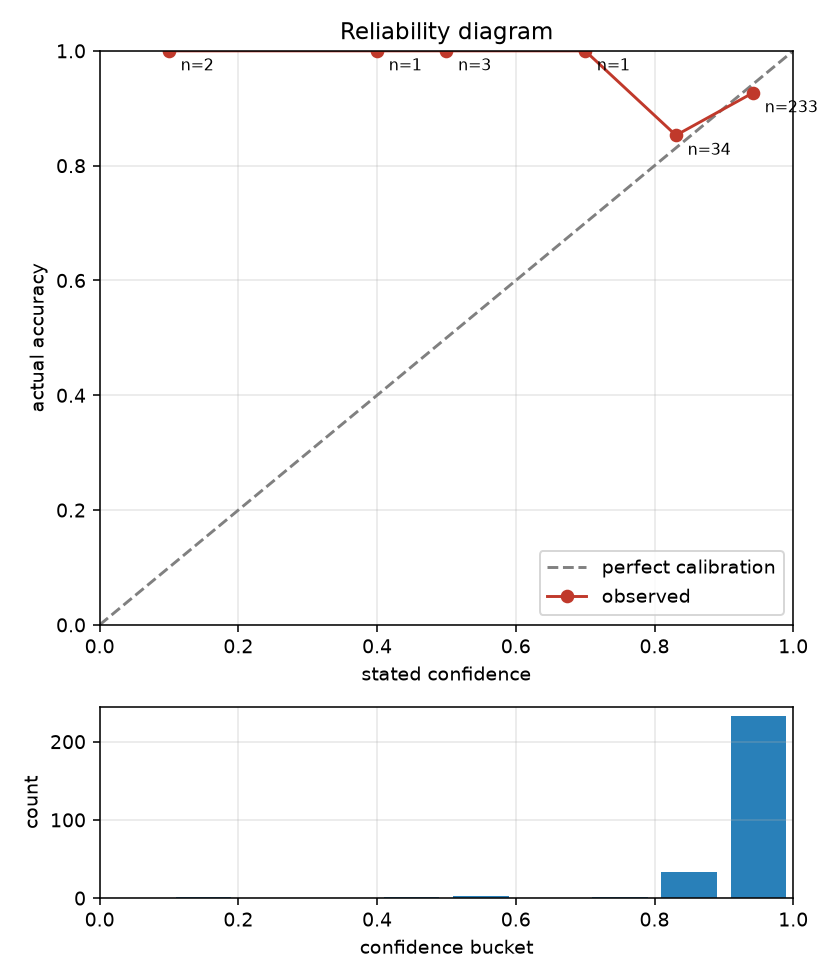

In [7]:
table([b for b in cal['buckets'] if b['n'] > 0], ['lo', 'hi', 'n', 'mean_confidence', 'accuracy', 'gap'])
print('high-confidence slice (>= 0.9):', cal['high_confidence_slice'])
print('out-of-distribution slice:     ', cal['ood_slice'])
p = R / f'calibration_{VERSION}.png'
if p.exists():
    display(Image(filename=str(p)))

### Findings

| | v1 | v2 |
|---|---|---|
| ECE | 0.031 | 0.129 |
| MCE | 0.90 | 0.90 |
| mean (confidence − correct) | −0.005 | −0.129 |
| accuracy when confidence ≥ 0.9 | 92.7% (n=233) | 99.1% (n=221) |
| mean confidence on ood | 0.69 | 0.32 |

**v1's low ECE is misleading.** Aggregate confidence (about 0.94) happens to sit near aggregate accuracy (92%),
but confidence barely varies: 0.95 was given 178 times out of 274, and 21 of the 22 wrong answers were stated at
0.85 or higher. The number does not separate right answers from wrong ones. v1 also gave 0.95 to "Explain
quantum entanglement in simple terms" (label correct, confidence meaningless).

**v2 is underconfident, and the cause is its own prompt rule.** v2 gave confidence 0.3 or lower to 23 answers,
and 22 of them were correct. 7 are real off-domain inputs, as intended. The other 15 are correct, in-scope
`other` tickets: job and internship questions, "Who is the CEO of your company?", chatter-only messages and their
typo variants. The rule "if the input is not about an order... confidence no higher than 0.3" turned confidence
into a "this is not a support ticket" signal, so it no longer measures how likely the label is to be right. The
only confident wrong answer in v2 is the empty input at 0.95.

**Caveats.** The confidence is a number the model writes, not a probability; it takes about ten distinct values.
The MCE of 0.90 in both runs comes from a bucket of 2 cases, and every bucket below 0.8 holds 18 cases or fewer.

**Proposed fix:** add a separate boolean field `in_scope` for "is this a support ticket", remove the confidence
cap, and keep `confidence` only for "is the category correct".

v2 reliability diagram:

![v2 reliability diagram](../results/calibration_v2.png)

## 7. Failure mode clusters

Each cluster represents a recurring failure pattern identified from the
evaluation results. For every cluster, report:

1. the observed failure pattern,
2. a model-behaviour hypothesis explaining why it occurs,
3. representative examples, and
4. one concrete improvement that could address the failure.

Do not claim a root cause that is not supported by the observed results.

In [8]:
table([{'cluster': c['label'], 'failures': c['n_failures'],
        'share': c['share_of_failures'], 'mean_conf': c['mean_confidence']}
       for c in clusters['clusters']], ['cluster', 'failures', 'share', 'mean_conf'])

for c in clusters['clusters']:
    print('=' * 78)
    print(f"{c['label']}  -  {c['n_failures']} failures, mean confidence {c['mean_confidence']}")
    print('-' * 78)
    print('WHY:', c['hypothesis'])
    print('\nFIX:', c['proposed_fix'])
    print('\nTop confusions:', c['top_confusions'])
    print('\nExamples:')
    for e in c['examples']:
        print(f"  [{e['test_id']}] {e['expected']} -> {e['predicted']} (conf {e['confidence']})")
        print(f"      {e['input'][:110]}")
    print()

| cluster | failures | share | mean_conf |
|---|---|---|---|
| Surface-form brittleness | 11 | 0.5 | 0.9091 |
| Taxonomy boundary confusion | 4 | 0.1818 | 0.9125 |
| Irrelevant-context capture | 3 | 0.1364 | 0.9 |
| Contradiction collapse | 3 | 0.1364 | 0.8833 |
| Negation blindness | 1 | 0.0455 | 0.85 |

Surface-form brittleness  -  11 failures, mean confidence 0.9091
------------------------------------------------------------------------------
WHY: The label moves when only the wording changes. Character noise and rewording break the token patterns the model relies on, which shows that the decision rests on lexical cues rather than the situation described. Typos also break verbatim span copying, so grounding degrades at the same time.

FIX: Add a normalisation pass in front of the classifier (spell correction limited to a domain dictionary) and make evidence_span a character offset pair into the original input rather than free text, so the model cannot silently repair the quote.

Top confusions: {'product_defect -> other': 3, 'other -> delivery': 2, 'other -> product_defect': 2, 'product_defect -> delivery': 1, 'account -> other': 1}

Examples:
  [adv_032] product_defect -> other (conf 0.95)
      Can this blender be used for hot liquids?
  [adv_045] other -> delivery (conf 0.95)
   

### Clusters reviewed by hand

The automatic clusters above come from rules on input type and keywords. Reading every failure showed that
they misattribute the largest group. v1's "surface-form brittleness" cluster has 11 failures, and 6 of them
(`adv_032`, `adv_047`, `adv_052`, `adv_194`, `adv_203`, `adv_209`) are paraphrase or typo variants of clean
tickets the model **also got wrong in their original form**, so the wording change did not cause them. Across all
18 of v1's adversarial failures, 10 inherit their error from a failing base case. The five clusters below come
from that reading. A–D cover the 22 v1 and 3 v2 category failures; E covers priority.

---

#### A. Category chosen by the most salient topic, not the customer's goal (v1: 14 of 22 failures, v2: 0)

**Pattern.** Four hard clean tickets, and every paraphrase, typo and distractor variant of them:
`gt_047` "Your app crashes on my phone..." → `product_defect`; `gt_041` "The return pickup was scheduled three
times and nobody came" → `delivery`; `gt_052` "...I just want the missing part sent to me" → `delivery`;
`gt_032` "Is this blender safe to use with hot liquids?" → `other`.

**Cause at the model-behaviour level.** v1's category definitions are topic lists that overlap: an app that
crashes also "does not work as sold", and a pickup that never came is also a "courier problem". With nothing to
break the tie, the model picks the category whose description best matches the most concrete event in the
ticket (crash, courier visit, something to be sent), not the customer's goal (a bug report, a refund, a
replacement part). The same error survives rewording, typos and added chatter, so this is a stable decision rule,
not noise.

**Fix (implemented as v2).** Written root-cause tie-break rules for each confused pair. It fixed all 14 cases with
no category regressions on them. To keep it fixed: add one regression test per tie-break rule, and add a
`secondary_category` field so a genuinely dual ticket can be scored as partially correct.

---

#### B. Label follows one category word, not what the sentence is doing (v1: 7 failures, v2: 1)

**Pattern.** `adv_045` and `adv_207`: praise that mentions "delivery" → `delivery`. `adv_050` "The device I got
isn't broken, but it's the wrong model" → `product_defect`. `adv_212`, a typo variant of the same ticket where
"not" became "ont" → `product_defect`. `adv_187` and `adv_192`: typos damage the cue word ("marketinge mails",
"slihtly ... phoot") → `other`. `adv_097`: distractor about a password manager → `account` (still fails on v2).

**Cause at the model-behaviour level.** The decision rests on a few category-bearing words ("delivery",
"broken", "password", "emails"). What a sentence is doing — thanking, denying, making a request — is carried
by short function words ("thanks", "not", "just wanted to say") that have little influence against a strong
domain noun. Typos make this visible from both sides: damaging the negation leaves a bare "defective", and
damaging the cue word leaves nothing, so the model falls back to `other`. Confidence stays 0.8–0.95, because
the model reacts to the presence of the cue, not to how well the sentence fits.

**Fix.** A two-step output: the model first returns `request_clause`, the verbatim sentence that states what the
customer wants (checked as a substring of the input like `evidence_span`), and the category must be justified from
that clause alone. Add 8–10 few-shot pairs for praise that mentions a category and negated category words. v2's
instructions already fixed 6 of 7. Also rewrite the password-manager distractor, which is itself a plausible
account complaint.

---

#### C. Conflicting facts resolved by the last concrete sentence (v1: 1 unique failure plus derived cases, v2: 1)

**Pattern.** `adv_116` "When will my order ship?... Though my bank statement shows no such transaction at
all." → `payment`, with the evidence span taken from the appended sentence. `adv_142` → `delivery`, following
"the tracking page says it was delivered yesterday". On v2, `adv_118` → `other` at confidence 0.3.

**Cause at the model-behaviour level.** The schema has no way to say "this ticket contradicts itself", so the
model must pick one reading. It anchors on the most recent concrete factual claim, which in these cases is the
appended contradiction. v2's instruction to cap confidence at 0.6 did lower mean contradiction confidence
(0.87 → 0.79), but the label choice still follows the same anchoring. The sample is small (3 cases), so this
cluster is the least certain.

**Fix.** Add `conflicting_claims: bool` with a required one-line explanation, route any ticket with
`conflicting_claims = true` to a human queue, and score the contradiction family on that flag, not on the
inherited label.

---

#### D. Empty input: the model classifies its own system prompt (v1: hallucinated span, v2: 1 failure at 0.95)

**Pattern.** `adv_222`, input `""`. v2 → `delivery` / `high` / 0.95, evidence span "Charged but the item never
arrived", a line copied from the v2 prompt.

**Cause at the model-behaviour level.** With no user text, the only text in the context is the system prompt. The
schema requires a non-empty evidence span, and the prompt tells the model to classify "the ticket", so it
treats the nearest text, its own instructions, as the ticket. v2's prompt contains realistic example complaints,
which makes a confident in-domain answer more likely than v1's shorter prompt did. Full analysis in section 5.

**Fix.** Reject input with no letters or digits before the model call and return `other` / `low` / confidence 0.
Add a detector rule that flags evidence spans of five or more words found in the system prompt but not in the
ticket.

---

#### E. Priority under-escalation (v1: 90 of 106 priority errors, v2: 44 of 58)

**Pattern.** Money-lost or unusable cases rated medium: `gt_010` (nine days late), `gt_035` (refund two weeks
overdue), `gt_038` (cancelled and not refunded), `gt_016` (someone else's order received). `high → medium`
alone is 65 errors on v1 and 30 on v2.

**Cause at the model-behaviour level.** The model rates priority by the tone and urgency of the language. These
tickets are calm and factual, with no "urgent" or "immediately". Applying the "money lost" rule needs an
inference ("nine days late" means lost; "not refunded" means money held) that the model does not make without
a trigger word, so it defaults to the middle option. Part of this is label policy: "nine days late = lost" is a
choice a second labeller might not make.

**Fix.** Stop asking for priority directly. Ask for five booleans, each with a verbatim evidence span:
`money_lost`, `access_blocked`, `unusable_or_unsafe`, `deadline_within_48h`, `needs_action`. Compute priority in
code: any of the first four → high; otherwise `needs_action` → medium; otherwise low. Each flag becomes
separately testable, and the rule is applied the same way every time.

## 8. Regression test

v1 is the baseline prompt. v2 introduces targeted changes based on the failure
modes observed in v1.

The regression runner compares each test individually rather than relying only
on aggregate accuracy. This identifies cases that passed under v1 but fail
under v2, allowing prompt changes to be evaluated for both improvements and
regressions.

In [9]:
p = R / 'regression_report.json'
if p.exists():
    reg = json.loads(p.read_text(encoding='utf-8'))
    table([{'field': k, 'value': v} for k, v in reg.items() if not isinstance(v, (list, dict))], ['field', 'value'])
    print('regressions by input type:', reg['regressions_by_input_type'])
    if reg['regressions']:
        table(reg['regressions'][:15], ['test_id', 'input_type', 'expected', 'before', 'after', 'confidence_after'])
    else:
        print('no regressions: every test that passed on v1 still passes on v2')
else:
    print('run: python -m evals.runner --prompt v2  then  python -m evals.regression')

| field | value |
|---|---|
| baseline | v1 |
| candidate | v2 |
| model | gemini-3.5-flash-lite |
| n_cases | 274 |
| n_scored_both | 274 |
| n_unscored | 0 |
| baseline_category_accuracy | 0.9197 |
| candidate_category_accuracy | 0.9891 |
| fixed | 21 |
| regressed | 2 |
| still_pass | 250 |
| still_fail | 1 |
| net_change | 19 |
| priority_fixed | 58 |
| priority_regressed | 10 |

regressions by input type: {'contradiction': 1, 'ood': 1}


| test_id | input_type | expected | before | after | confidence_after |
|---|---|---|---|---|---|
| adv_118 | contradiction | delivery | delivery | other | 0.3 |
| adv_222 | ood | other | other | delivery | 0.95 |

### Findings

| | count |
|---|---|
| cases compared (scored on both runs) | 274 |
| category fixed (fail on v1 → pass on v2) | 21 |
| category regressed (pass on v1 → fail on v2) | 2 |
| net change | +19 |
| priority fixed / regressed | 58 / 10 |

The aggregate numbers alone (92.0% → 98.9%) would have hidden both regressions, and both were caused by v2's
own new instructions:

- **`adv_222` (ood):** `other` → `delivery` at 0.95. The longer v2 prompt gave the model example complaints to
  quote when the input was empty.
- **`adv_118` (contradiction):** `delivery` → `other` at 0.3. The off-domain confidence rule fired on a genuine
  delivery question.

**Decision.** v2 is better and should replace v1, but only with the empty-input guard from cluster D. Its
confidence values should not be used for routing until the `in_scope` field replaces the 0.3 cap (section 6). Any
v3 must be checked with this runner against v2, not only against v1.

The runner treats a case that errored on either run as unscored instead of as a failure, so a quota or network
failure cannot show up as a false regression.

## 9. Limitations and next steps

### Limitations

- **Small dataset.** 52 base tickets; one clean case is worth 1.9 points of clean accuracy, and most per-type
  and per-bucket numbers rest on a handful of failures.
- **Not held out.** v2's rules were written after reading v1's failures on these exact cases. v2's 100% clean
  accuracy shows that the rules fix the cases they were written for, not that they generalise.
- **Ground truth.** LLM-drafted, then reviewed and corrected by one person. There is no second labeller and no
  agreement score, and the tickets are cleaner than real support traffic.
- **One model.** Every result is for `gemini-3.5-flash-lite`; other models may fail differently.
- **Determinism measured only through the cache.** Temperature 0 and a fixed seed were used, but the run-to-run
  variance of fresh API calls was not measured; the reported numbers replay cached responses.
- **Adversarial families chosen by the author**, and therefore biased towards expected failures. The negation
  family found nothing, one distractor is itself a valid complaint (`adv_097`), inherited labels can be wrong
  (`adv_118`), and paraphrases come from the model family under test.
- **Hallucination check is presence-only.** It verifies that a span exists in the ticket, not that it supports
  the label, and it does not reconcile number and word forms.
- **Calibration rests on verbalized confidence**, about ten distinct values, with small low-confidence buckets.
  The MCE of 0.90 comes from 2 cases.
- **Automatic clusters are rule-based** and mislabelled the largest group; section 7's clusters come from reading
  every failure by hand.

### Most valuable next experiment

Write a **held-out set of about 50 new tickets**, ideally anonymised real tickets, labelled independently by a
second person before either sees the model's answers. Report inter-annotator agreement (Cohen's kappa) and rerun
v1 and v2 on it. This answers the one question this report cannot: whether v2's gains generalise or only fit the
cases it was tuned on. The priority-flag redesign from cluster E is the most valuable system change, because
priority is now the largest source of errors.

### One more adversarial category

**Multi-issue tickets**: a single message with two real problems of different priority, for example "My refund
is two weeks late, and also how do I change my email?". This tests whether the model picks the higher-priority
issue or the one it reads first. Label each case with the most severe issue, and store the second issue so the
`secondary_category` fix can be scored.